# Data Mining Lab 1
## Data Understanding + Data Cleaning + Visualization  
**Dataset:** StudentsPerformance.csv

**Зорилго:**  
- Бодит dataset ашиглан өгөгдлийг унших, таних  
- Алдаа, дутуу утга, давхардлыг шалгаж цэвэрлэх  
- Энгийн график дүрслэлээр pattern-ийг олж харах  



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 0) Dataset унших

**StudentsPerformance.csv** файлыг ашиглана.


In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1) Data Understanding (өгөгдлөө таних)

### 1.1 Dataset-ийн бүтэц
- Хэдэн мөр, хэдэн баганатай вэ?  
- Аль баганууд numeric байна вэ?  
- Аль багана нь ирээдүйд prediction хийхэд тохиромжтой вэ?


In [3]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.dtypes


Shape: (1000, 8)
Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

### 1.2 Missing болон duplicate шалгах

- Аль баганад missing value байна вэ?  
- Давхардсан мөр байгаа эсэх?


In [4]:
# Missing values
df.isna().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
# Duplicate rows
df.duplicated().sum()


np.int64(0)

### 1.3 Үндсэн статистик

Эндээс:
- Math, Reading, Writing score-уудын ерөнхий тархалтыг харна  
- Аль score хамгийн өндөр дундажтай байна вэ?


In [6]:
df.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000



1. Gender ба score-уудын хооронд ялгаа байна уу? (таамаг)  
2. Lunch төрлөөс score хамаарах уу?  
3. Аль score (math, reading, writing) хамгийн тогтвортой мэт харагдаж байна вэ?


## 2) Data Cleaning (өгөгдөл цэвэрлэх)

Энэ dataset-д ихэнхдээ missing бага эсвэл байхгүй байдаг.  
Гэхдээ дараах алхмуудыг **заавал шалгана**:

- Missing value  
- Category data-г ялгаж харах  
- Numeric data-г тусад нь авч үзэх


In [7]:
# Numeric болон categorical баганууд
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))


Numeric columns: ['math score', 'reading score', 'writing score']
Categorical columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


## 3) Visualization (график дүрслэл)

Энд бид өгөгдөл доторх **pattern-ийг нүдээрээ олж харна**.


### 3.1 Histogram – Math score
- Дийлэнх оюутнууд аль score орчимд байна вэ?


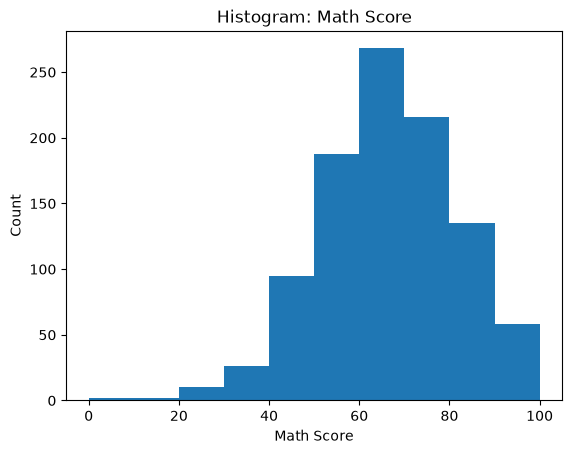

In [8]:
plt.figure()
plt.hist(df['math score'], bins=10)
plt.title("Histogram: Math Score")
plt.xlabel("Math Score")
plt.ylabel("Count")
plt.show()


### 3.2 Scatter – Math vs Reading
- Эдгээр хоёр score хоорондоо холбоотой юу?


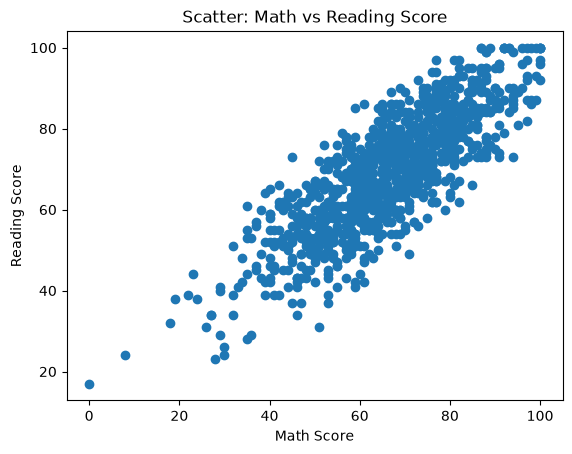

In [9]:
plt.figure()
plt.scatter(df['math score'], df['reading score'])
plt.title("Scatter: Math vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()


### 3.3 Boxplot – Gender vs Math Score
- Gender хооронд ялгаа ажиглагдаж байна уу?


<Figure size 640x480 with 0 Axes>

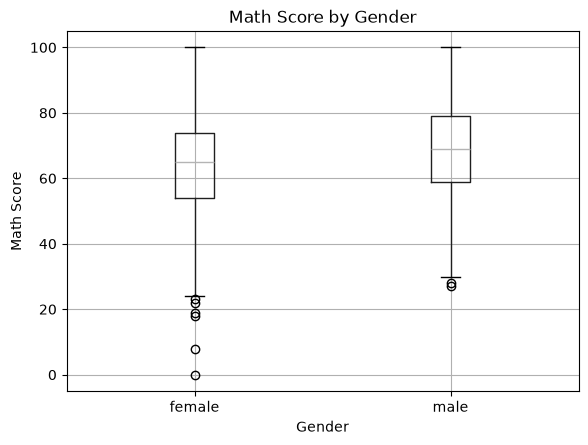

In [10]:
plt.figure()
df.boxplot(column='math score', by='gender')
plt.title("Math Score by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Math Score")
plt.show()


### 3.4 Correlation Heatmap (numeric features)

- Math, Reading, Writing score-уудын correlation-ийг харна  
- Аль хоёр нь хамгийн өндөр холбоотой вэ?


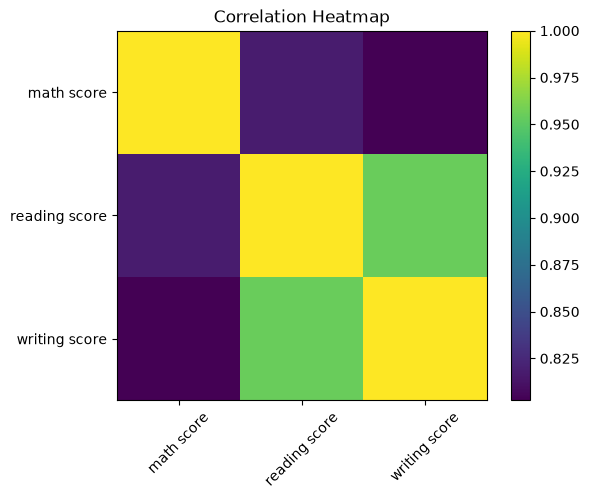

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [11]:
scores = df[['math score','reading score','writing score']]
corr = scores.corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(scores.columns)), scores.columns, rotation=45)
plt.yticks(range(len(scores.columns)), scores.columns)
plt.title("Correlation Heatmap")
plt.show()

corr


## TASK A: Feature Analysis

Доорх асуултуудад **Python код бичиж** хариулна уу.

1. Аль categorical feature (`gender`, `lunch`, `test preparation course`) нь
   math score-т хамгийн их ялгаа үүсгэж байна вэ?
2. Тухайн feature бүрээр math score-ийн **дундаж**-ийг тооцоол.
3. Ямар feature нь prediction хийхэд илүү ашигтай санагдаж байна вэ? (үгээр)

`groupby()` + `mean()` ашиглана уу.


In [12]:
# code
high_math = df[df['math score'] >= 70]['reading score'].mean()
low_math = df[df['math score'] < 70]['reading score'].mean()

print("Math >= 70  -> mean Reading:", high_math)
print("Math < 70   -> mean Reading:", low_math)
print("Difference:", high_math - low_math)

Math >= 70  -> mean Reading: 80.25916870415648
Math < 70   -> mean Reading: 61.49407783417936
Difference: 18.765090869977122


##  TASK B: Score Comparison

1. Math, Reading, Writing score-уудын **variance** (эсвэл std)-ийг тооцоол.
2. Аль score хамгийн их хэлбэлзэлтэй байна вэ?
3. Энэ нь суралцахад юуг илэрхийлж болох вэ? (үгээр)

 `var()` эсвэл `std()` ашиглана уу.


In [13]:
# code
print(df[['math score', 'reading score', 'writing score']].var())
print(df[['math score', 'reading score', 'writing score']].std())

math score       229.918998
reading score    213.165605
writing score    230.907992
dtype: float64
math score       15.163080
reading score    14.600192
writing score    15.195657
dtype: float64


## TASK C: Simple Rule Thinking

Доорх энгийн дүрмүүдийг шалгаарай.

1. Math score ≥ 70 оюутнуудын дундаж Reading score хэд вэ?
2. Math score < 70 оюутнуудын дундаж Reading score хэд вэ?
3. Эдгээрийн ялгаа нь ямар **pattern**-ийг харуулж байна вэ?

Boolean filter + `mean()` ашиглана уу.


In [14]:
# code
high_math = df[df['math score'] >= 70]['reading score'].mean()
low_math = df[df['math score'] < 70]['reading score'].mean()

print("Math >= 70  -> mean Reading:", high_math)
print("Math < 70   -> mean Reading:", low_math)
print("Difference:", high_math - low_math)

Math >= 70  -> mean Reading: 80.25916870415648
Math < 70   -> mean Reading: 61.49407783417936
Difference: 18.765090869977122


# Data Mining Lab 1 Тайлан 
## Student Performance Dataset

**Нэр:** Enkhtur Erkhes  
**Оюутны код:** s22c067b  
**Анги / Бүлэг:** KU-5  
**Огноо:** 2026/09/21  

---

## 1. Dataset-ийн ерөнхий мэдээлэл
- Мөрийн тоо: 1000
- Баганын тоо: 8
- Target variable (хэрэв байвал): `math score` (predict хийх target болгон ашиглаж болно)

Энэ dataset нь 1000 сурагчийн хүйс (gender), угсаатны бүлэг (race/ethnicity),
эцэг эхийн боловсролын түвшин, хоолны төрөл (lunch), шалгалт бэлтгэлийн
хичээлд хамрагдсан эсэх болон математик, уншлага, бичлага гэсэн 3 хичээлийн
оноог агуулна. Oноонууд 0–100 хооронд байна.

---

## 2. Data Understanding (Өгөгдөл таних)

### Numeric Features
- `math score` – математикийн оноо (0–100, дундаж 66.09)
- `reading score` – уншлагын оноо (0–100, дундаж 69.17)
- `writing score` – бичлагын оноо (0–100, дундаж 68.05)

### Categorical Features
- `gender` – female / male
- `race/ethnicity` – group A – group E
- `parental level of education` – high school, some high school, some college,
  associate's, bachelor's, master's degree
- `lunch` – standard / free/reduced
- `test preparation course` – none / completed

`describe()`-оос ажиглагдсан гол зүйлс:
- Reading score хамгийн өндөр дундажтай (69.17), math хамгийн бага (66.09).
- Math score-ийн min = 0, тухайн сурагч бусад хичээлдээ ч маш бага
  (reading 17, writing 10) байгаа нь хэвийн тархалтын хамгийн доод хэсэг.
- 25%–75% хооронд оноонууд ойролцоогоор 57–79 байна (бие даасан тархалт).

---

## 3. Data Cleaning (Өгөгдөл цэвэрлэгээ)
- Missing value байсан уу? **Үгүй** (бүх баганад 0)
- Хэрхэн шийдсэн бэ? Missing value байгаагүй тул шийдвэрлэх шаардлага гарсангүй.
- Duplicate мөр байсан уу? **Үгүй** (`df.duplicated().sum()` = 0)


---

## 4. Visualization ба Pattern

### Visualization 1
- Төрөл: **Histogram** (Math score)
- Ажиглагдсан pattern: Оноонууд бараг хэвийн тархалттай, дийлэнх сурагчид
  50–80 онооны хооронд байна. Мод нь 60–70 байна.

### Visualization 2
- Төрөл: **Scatter plot** (Math vs Reading)
- Ажиглагдсан pattern: Цэгүүд диагональ дагуу бөөгнөрсөн нь math болон reading
  оноо хоорондоо холбоотой болохыг харуулна (correlation = 0.82).

---

## 5. Correlation Analysis
- Хамгийн өндөр correlation: **Reading score ↔ Writing score (0.9546)**
- Уншлага сайн сурагч сайн бичдэг —
  хоёр чадвар нэгэн адил "хэлний/текстийн чадвар"-тай холбоотой. Тиймээс
  нэгийг нь мэдвэл нөгөөd нь маш сайн байх боломжтой.

---

## 6. Дүгнэлт
Энэ лабораторид би pandas ашиглан бодит dataset-г уншиж, `isna()`,
`duplicated()`, `describe()`, `groupby()`, `var()/std()`, boolean filter зэрэг
функцууд ашиглан өгөгдлийг шалгаж үзэв. Visualization болон correlation дүрслэл
ашиглан math–reading (0.82), reading–writing (0.95) хооронд хүчтэй
холбоо байгааг, мөн lunch төрөл болон test preparation course нь math оноонд
мэдэгдэхүйц нөлөөтэйг (ялангуяа lunch ~11 онооны ялгаа) тогтоолоо. Энэ нь
ирээдүйд regression/classification моделд оноог таамаглах feature сонгоход
чухал суурь мэдлэг өглөө.